# Samna 0.14.6 Demo

## Introduction to the DYNAP-SE1 board and API

The board had 4096 AdEx LIF (Adaptive Exponential Leaky Integrate-and-fire) analog spiking neurons implemented with DPI circuits.

We can change some paramters of the neurons and the connectivity matrix, but the emulation is 'always on' once the chip is powered up.

Samna provides Python API to interact with the board. The only board output that cannot be monitored digitally are neuron memrane voltages.

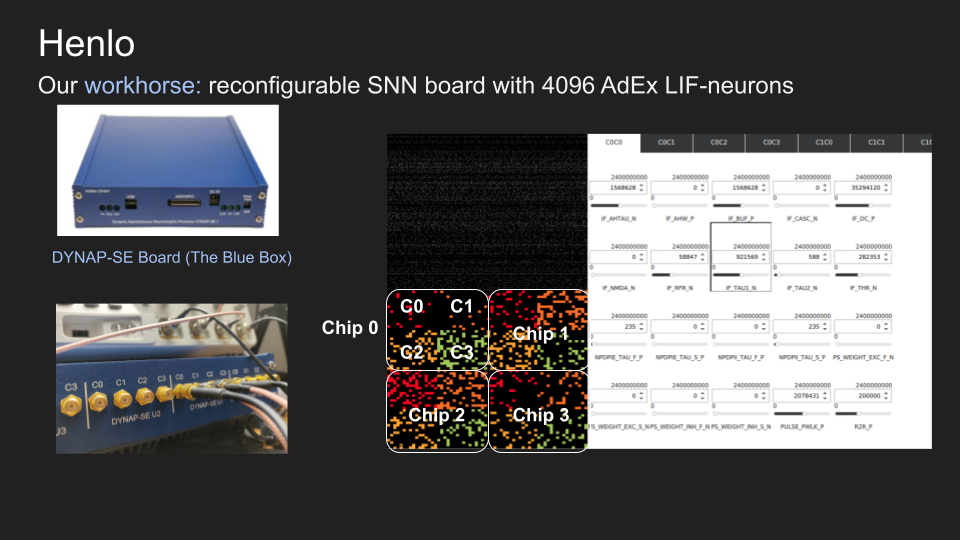

Biases control currents through specific transistors. Various individual blocks of the circuits, such as spike frequency adaptation or synaptic input, can be disabled just by the configuration of the biases.

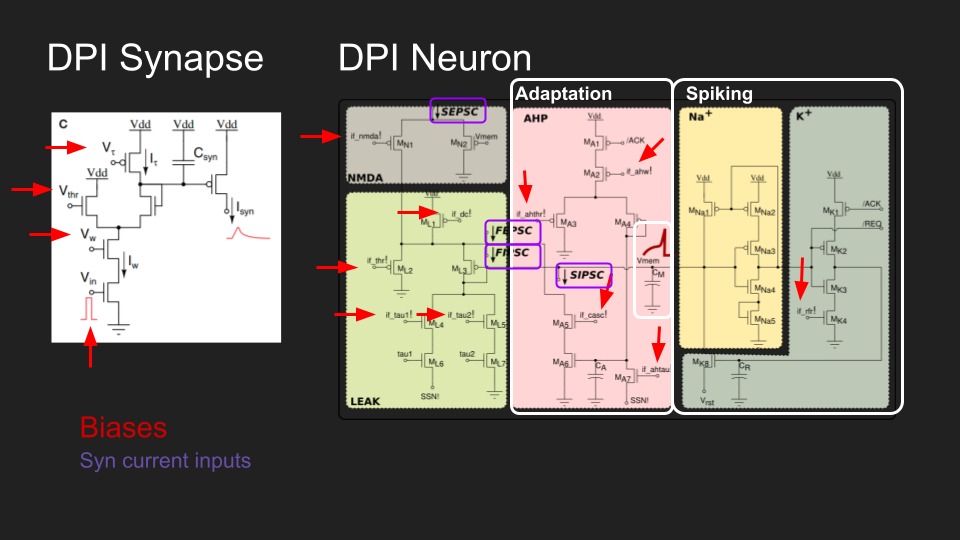

Some quantities we can measure directly with the oscilloscope

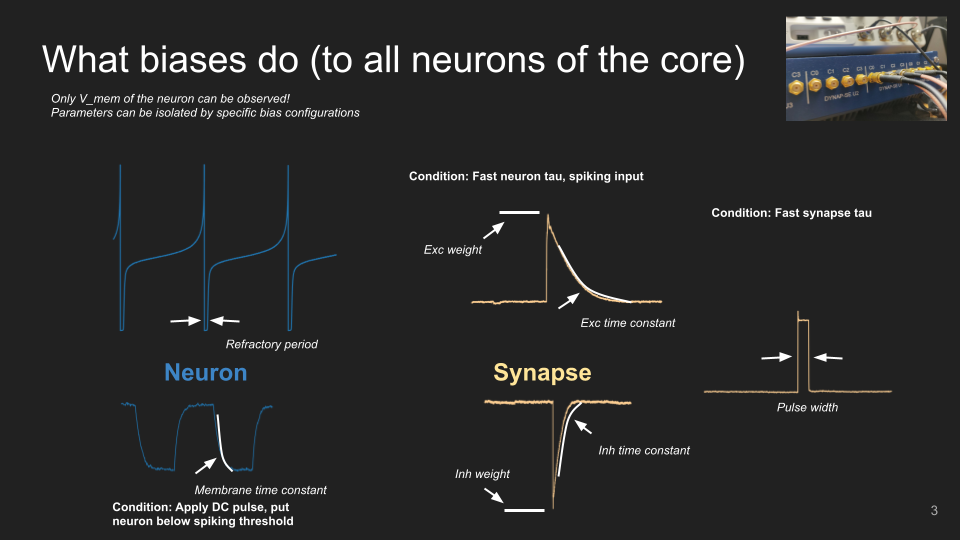

## Samna architecture

We interact with the state of board through the `model`.
The `configuration` object contains two main sub objects:

i) `Parameter group` containing bias values

ii) Network connectome (list of neuron-to-neuron connections)


To update the state of the board we can either retreive the current configuration and modify it, or create a new one completely.
The state of the board is only updated only when `update_parameter_group()` or `apply_configuration()` methods are called.




#### Sending and receiving spikes from the board is done separately from state management.

Input spikes are preloaded onto the FPGA and then sent to the physical neurons via created connections.

Output spikes are filtered and recorded using the `Event Graph` system.

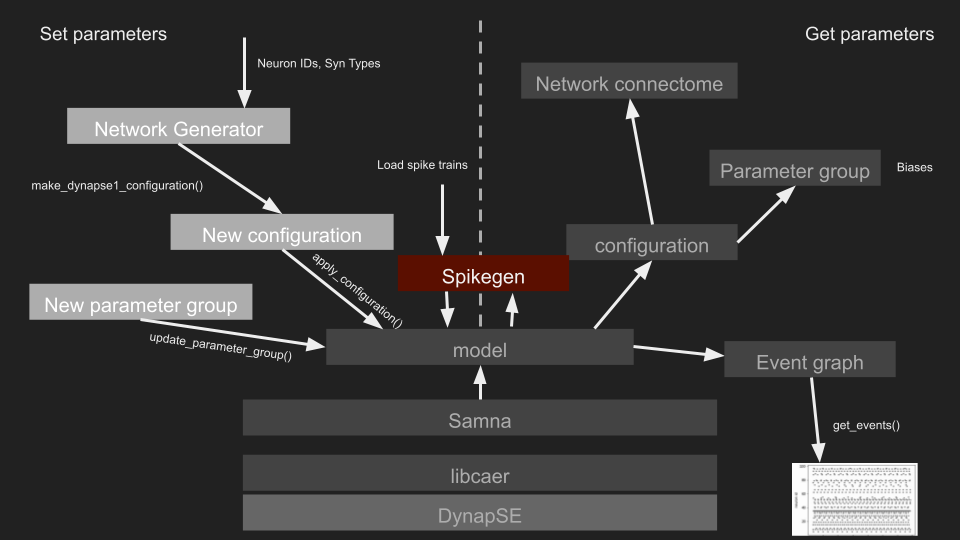

Let's run some code now.

### 1. Start Samna

In [1]:
import samna
import samna.dynapse1 as dyn1

import sys
sys.path.append("/home/dzenn/Documents/pygetscope/")


from dynapse1constants import *
import dynapse1utils as ut
import netgen as n
from netgen import Neuron
import time
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# open DYNAP-SE1 board to get Dynapse1Model
device_name = "dynapse1"

# open with GUI
model, gui_thread = ut.open_dynapse1(device_name)

# open without GUI
#store = ut.open_dynapse1(device_name, gui=False)

[0]:  Bus 1 Device 5 Dynapse1DevKit serial_number 00000002
Visualizer start command:  /home/dzenn/anaconda3/bin/python -c "import samna, samnagui; samnagui.runVisualizer(0.75, 0.75, 'tcp://0.0.0.0:33335', 'tcp://0.0.0.0:33336', 3)"
GUI receiving port: tcp://0.0.0.0:82260
GUI node ID: 3
Sender port: tcp://0.0.0.0:33336
Receiver port: tcp://0.0.0.0:33335
Opened device name: dynapse1
SamnaNode ID: 1
PythonNode ID: 2


### Get the model (for samna 0.8 or older)

In [3]:
model = getattr(store, device_name)

#### Give the model to the bias GUI (if the Dynapse board is connected locally)

In [3]:
from sliderGui import run_threaded_gui

run_threaded_gui(model)

#gui = sliderGui(model)

#### Monitor single neurons with oscilloscope (if it is connected locally as well)

In [87]:
api  =  model.get_dynapse1_api()

chip_id = 1
neuron_id = 10

api.monitor_neuron(chip_id, neuron_id)

#### Oscilloscope setup

In [5]:
from py_scope import PyScope

my_scope = PyScope()

Identification string 'AGILENT TECHNOLOGIES,DSO6054A,MY44002200,06.16.0001
'
Timeout set to 15 s.
Init successful


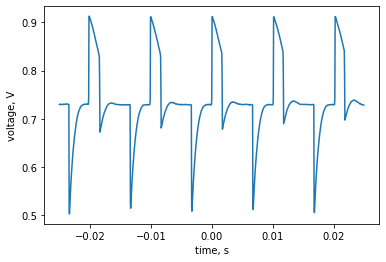

In [130]:
wf = my_scope.get_waveform(channel=1, instant_plot=True)

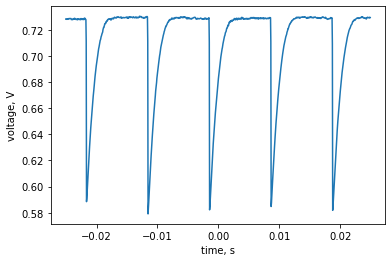

In [115]:
wf2= my_scope.get_waveform(channel=1, instant_plot=True)

In [ ]:
plt.plot(

## 2. Board Configurations

### Let's see what's inside the configuration

Configuration represents state of the device

In [14]:
config1 = model.get_configuration()

In [15]:
dir(config1.chips[0].cores[0])

['__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'chip_id',
 'core_id',
 'from_json',
 'neurons',
 'parameter_group',
 'to_json']

### Check biases in the parameter group

In [17]:
print("Linear: " + str(config1.chips[1].cores[0].parameter_group.get_linear_parameter('IF_TAU1_N')))
print("Coarse: " + str(config1.chips[1].cores[0].parameter_group.param_map['IF_TAU1_N'].coarse_value))
print("Fine: " + str(config1.chips[1].cores[0].parameter_group.param_map['IF_TAU1_N'].fine_value))

Linear: 2019608.0
Coarse: 4
Fine: 103


In [9]:
param_group = config1.chips[0].cores[0].parameter_group


In [10]:
param_group.param_map.keys()

dict_keys(['IF_AHTAU_N', 'IF_AHTHR_N', 'IF_AHW_P', 'IF_BUF_P', 'IF_CASC_N', 'IF_DC_P', 'IF_NMDA_N', 'IF_RFR_N', 'IF_TAU1_N', 'IF_TAU2_N', 'IF_THR_N', 'NPDPIE_TAU_F_P', 'NPDPIE_TAU_S_P', 'NPDPIE_THR_F_P', 'NPDPIE_THR_S_P', 'NPDPII_TAU_F_P', 'NPDPII_TAU_S_P', 'NPDPII_THR_F_P', 'NPDPII_THR_S_P', 'PS_WEIGHT_EXC_F_N', 'PS_WEIGHT_EXC_S_N', 'PS_WEIGHT_INH_F_N', 'PS_WEIGHT_INH_S_N', 'PULSE_PWLK_P', 'R2R_P'])

### The full list of biases:

- IF_AHTAU_N - Neuron’s firing threshold adaptation time constant
- IF_AHTHR_N - Neuron’s firing threshold max value
- IF_AHW_P - Neuron’s firing threshold adaptation weight (how much the threshold rises with each spike) 
- IF_BUF_P - N\A
- IF_CASC_N - Enables firing threshold adaptation
- IF_DC_P - DC current injected into a neuron
- IF_NMDA_N - Enable NMDA gating
- IF_RFR_N - Neuron refractory period
- IF_TAU1_N - Main neuron time constant (unless switched to TAU2)
- IF_TAU2_N - Secondary time constant (for every neuron either TAU1 or TAU2 can be selected)
- IF_THR_N - Neuron V_mem gain (not the firing threshold!)
- NPDPIE_TAU_F_P - Fast excitatory (AMPA) synapses time constant
- NPDPIE_TAU_S_P - Slow excitatory (NMDA) synapses time constant
- NPDPIE_THR_F_P - Fast excitatory (AMPA) synapses threshold (i.e. max I_syn value)
- NPDPIE_THR_S_P - Slow excitatory (NMDA) synapses threshold (i.e. max I_syn value)
- NPDPII_TAU_F_P - Fast inhibitory (GABA_A) synapses time constant
- NPDPII_TAU_S_P - Slow inhibitory (GABA_B) synapses time constant
- NPDPII_THR_F_P - Fast inhibitory (GABA_A) synapses threshold ((i.e. max I_syn value)
- NPDPII_THR_S_P - Slow inhibitory (GABA_B) synapses threshold (i.e. max I_syn value)
- PS_WEIGHT_EXC_F_N - Fast excitatory (AMPA) synapse weights
- PS_WEIGHT_EXC_S_N - Slow excitatory (NMDA) synapse weights
- PS_WEIGHT_INH_F_N - Fast inhibitory (GABA_A) synapse weights
- PS_WEIGHT_INH_S_N - Slow inhibitory (GABA_B) synapse weights
- PULSE_PWLK_P - Pulse width for synapses
- R2R_P - N\A


### 2.1 Updating biases on the board

In [11]:
param_group.param_map['IF_TAU1_N'].fine_value = 200
param_group.param_map['IF_TAU1_N'].coarse_value = 6

In [12]:
model.update_parameter_group(param_group, 0, 0)

#### Neurons

In [17]:
neurons = config1.chips[2].cores[0].neurons

In [18]:
len(neurons)

256

Neuron attributes

In [19]:
print(neurons[0].chip_id)
print(neurons[0].core_id)

2
0


# 3. Event Graph: retreiving spikes from the board

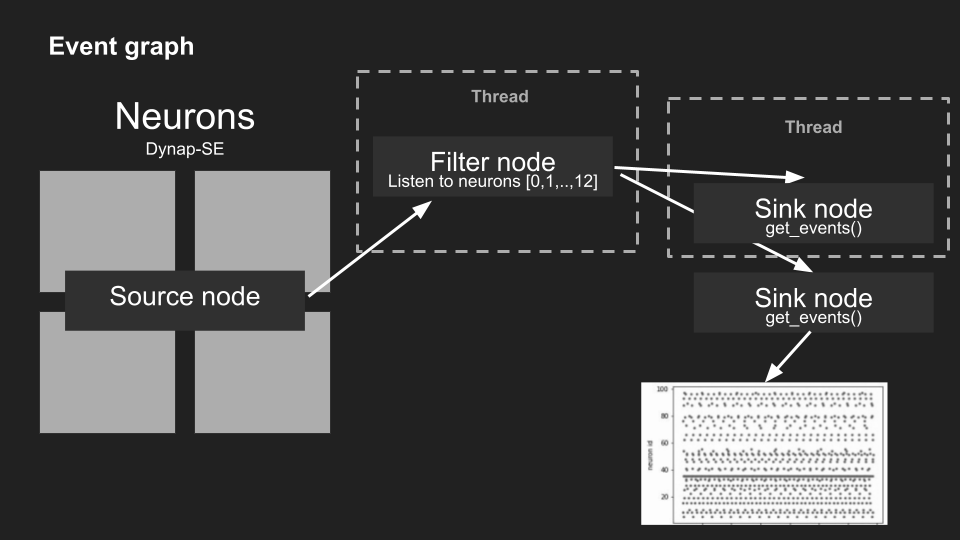

### Specifying the neurons we are interested in

IDs go as triplets (chip_id, core_id, n_id)

In [68]:
global_ids = np.array([1,2,3,4,5,6])
neuron_ids = np.array([[1, 0, n_id] for n_id in global_ids])

### Create a graph that would give us the events from the specified neurons

In [19]:
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, neuron_ids)


In [69]:
# Never forget to start the graph!

graph.start()

False

### Let's get some events

In [27]:
evts = sink_node.get_events()
len(evts)

114

#### We can edit the filter node on the fly:

In [35]:
#filter_node.set_neurons(global_ids)
filter_node.set_neurons([[1, 0, n_id] for n_id in np.arange(0,100)])

In [73]:
filter_node.set_neurons(neuron_ids)

In [41]:
graph.stop()

True

### Get some events and plot them instantly

221


Text(0, 0.5, 'neuron id')

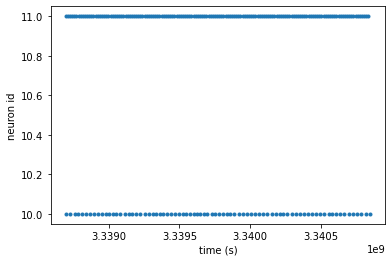

In [75]:
evts = sink_node.get_events()


print(len(evts))
evts_n = np.array([[evt.timestamp, evt.neuron_id] for evt in evts])

plt.plot(evts_n[:,0], evts_n[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("neuron id")

#### You can see the emulation is always running!

### Fancy online plotting (only if the board is connected locally):

In [28]:
import Activity_plotter

In [57]:
graph_live, filter_node_live, sink_node_live = ut.create_neuron_select_graph(model, neuron_ids)
filter_node_live.set_neurons([[1, 0, n_id] for n_id in np.arange(0,200)])
graph_live.start()

True

In [58]:
Activity_plotter.run_plotting_thread(sink_node_live, refresh_rate = 200)

## 4. Providing input to the chip from the FPGA

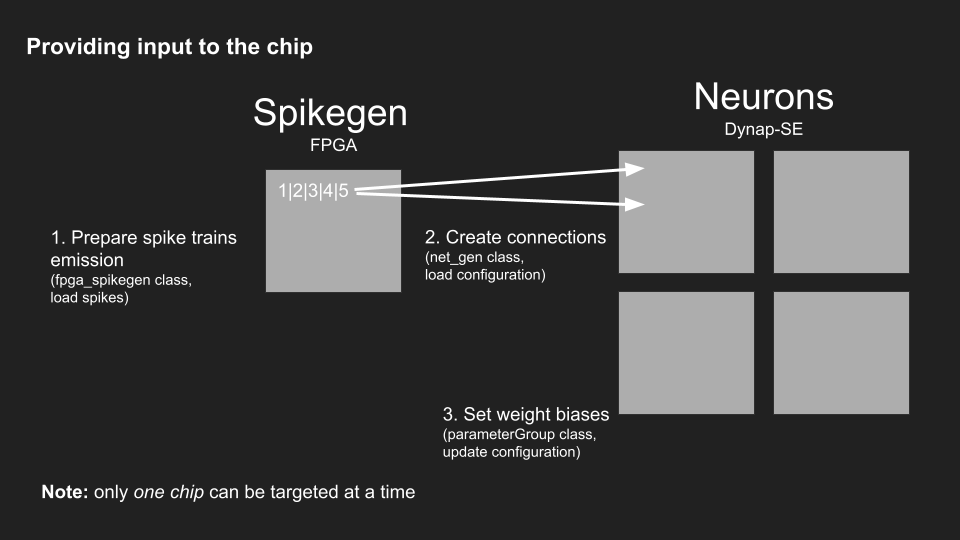

## 4.1 Preparing the spike trains

In [44]:
spikegen_ids = [1, 2]

Things to keep in mind:

In [86]:
#Maximum ISI. Can be avoided with dummy spikes
MAX_ISI = 2**ISI_NUM_BITS-1
print(str(MAX_ISI*1e-06 * 10) + " s")

0.65535 s


In [87]:
#Maximum spike train length
MAX_LEN = 2**ADDR_NUM_BITS-1
print(MAX_LEN)

32767


In [89]:
#Spike train of spikegen 1
timestamps1 = np.linspace(0,1,100)
indices1 = np.ones(len(timestamps1))*spikegen_ids[0]

timestamps2 = np.linspace(0,1,200)
indices2 = np.ones(len(timestamps2))*spikegen_ids[1]

Text(0, 0.5, 'spikegen')

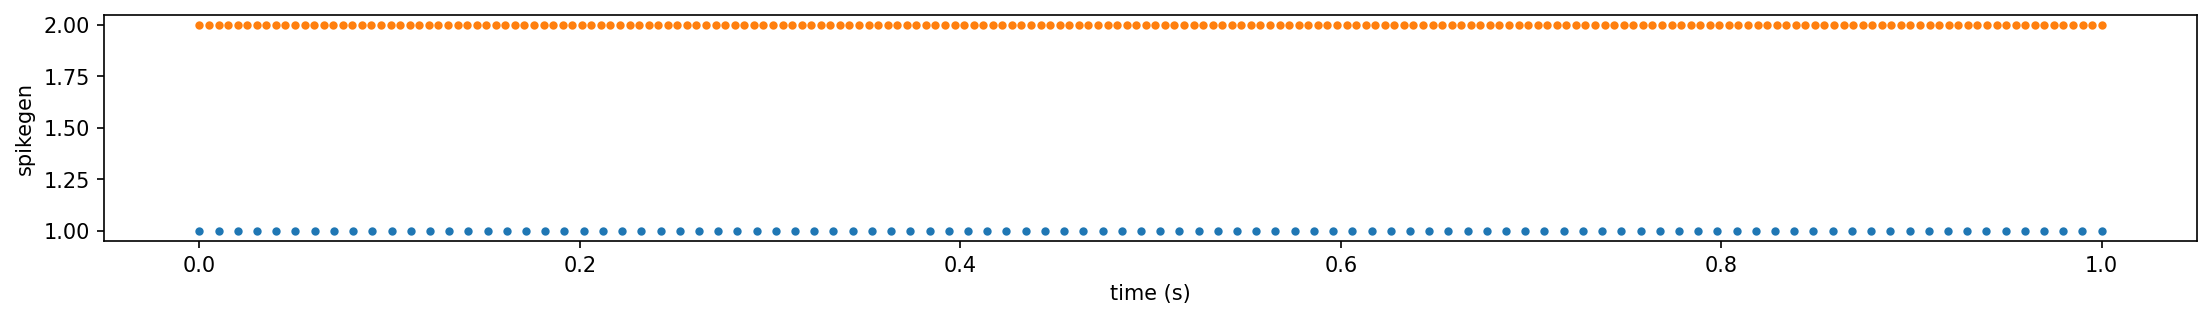

In [90]:
plt.figure(figsize=(18,2), dpi=150)
plt.plot(timestamps1, indices1, '.')
plt.plot(timestamps2, indices2, '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [91]:
# Create a single SORTED spiketrain

spiketrain = np.concatenate((np.column_stack((timestamps1,indices1)), np.column_stack((timestamps2,indices2))))


In [ ]:
spiketrain

In [95]:
spiketrain = spiketrain[spiketrain[:,0].argsort()]

Text(0, 0.5, 'spikegen')

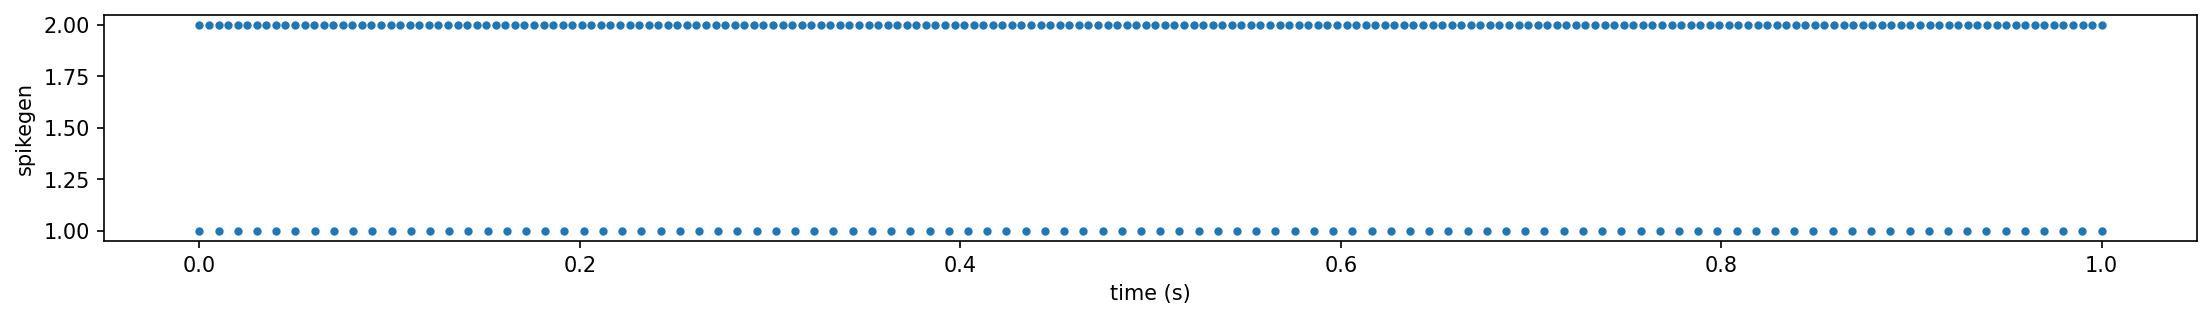

In [96]:
plt.figure(figsize=(18,2), dpi=150)
plt.plot(spiketrain[:,0], spiketrain[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [93]:
fpga_spike_gen = model.get_fpga_spike_gen()
target_chip = 1

In [98]:
ut.set_fpga_spike_gen(fpga_spike_gen, spike_times=spiketrain[:,0], indices=spiketrain[:,1].astype(int), target_chips=[target_chip]*len(spiketrain), isi_base=900, repeat_mode=True)

New configuration applied to DYNAP-SE1!
VariableIsiMode already 1
RepeatMode already 1


In [99]:
fpga_spike_gen.start()

In [97]:
fpga_spike_gen.stop()

### 4.2 Connect Spike Generator

In [73]:
import netgen as n
from netgen import Neuron

In [74]:
# if we look at the Neuron object, we see that is has a flag whether it is virtual or not. Virtual neurons are spike emitters on the FPGA
help(Neuron)

Help on class Neuron in module netgen:

class Neuron(builtins.object)
 |  Neuron(chip_id=0, core_id=0, neuron_id=0, is_spike_gen=False)
 |  
 |  Attribute:
 |      chip_id, core_id, neuron_id: int
 |      is_spike_gen: bool, if this neuron is a spike generator on the FPGA or a physical neuron on chip.
 |      incoming_connections: a dictionarty which stores the incoming_connections. Only starts to play a role after add_connection(pre, neuron).
 |          key: tuple, (pre.core_id,pre.neuron_id,synapse_type).
 |              Corresponds to cam. Divide the connections by its cam value for cam reuse.
 |          value: list, [(pre.chip_id, pre.is_spike_gen), (pre.chip_id, pre.is_spike_gen),...].
 |              To tell if the post neurons are the same neuron. get the connection weight.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Only compares the ids. Consider a neuron as an individual neuron without any external connections (i.e. not in a Network)
 |  
 |  __hash_

In [57]:
# Let's create 2 virtual neurons

spikegen_neuron1 = Neuron(0,0,1,is_spike_gen=True)
spikegen_neuron2 = Neuron(0,0,2,is_spike_gen=True)

In [54]:
# Let's target neurons 10 and 11

neurons = [Neuron(1,0,10), Neuron(1,0,11)]

In [118]:
# initialize a networkgenerator

net_gen = n.NetworkGenerator()

In [119]:
# All these connections are stored (or 'staged') locally and are not applied to the board right away

#net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.AMPA)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.AMPA)
net_gen.add_connection(spikegen_neuron2, neurons[0], dyn1.Dynapse1SynType.GABA_A)

In [120]:
# print the network so you can double check (optional)
net_gen.print_network()

Post neuron (ChipId,coreId,neuronId): incoming connections [(preNeuron,synapseType), ...]
C1c0n10: [('C0c0s1', 'AMPA'), ('C0c0s2', 'GABA_A')]



In [60]:
net_gen.remove_connection(spikegen_neuron2, neurons[1], dyn1.Dynapse1SynType.AMPA)

In [121]:
# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

In [122]:
# apply the configuration
model.apply_configuration(new_config)

### Alternatively - Poisson spike generator

In [119]:
# poissongen_id, range = [0, 1024)
poissongen_id = 1
rate = 200

# get poissongen from the model
poisson_gen = model.get_poisson_gen()
# set the target chip of the post neurons
post_chip = 1
poisson_gen.set_chip_id(post_chip)
poisson_gen.write_poisson_rate_hz(poissongen_id, rate)

# remember to start the poissongen
poisson_gen.start()

In [120]:
poisson_gen.stop()

## Remember to adjust biases!

Now we can see that we can add and remove connections on the fly

Let's get spikes from those two neurons

In [115]:
filter_node.set_neurons([(1,0,10),(1,0,11)])

In [98]:
graph.start()

False

Spikes collected: 533


Text(0, 0.5, 'neuron id')

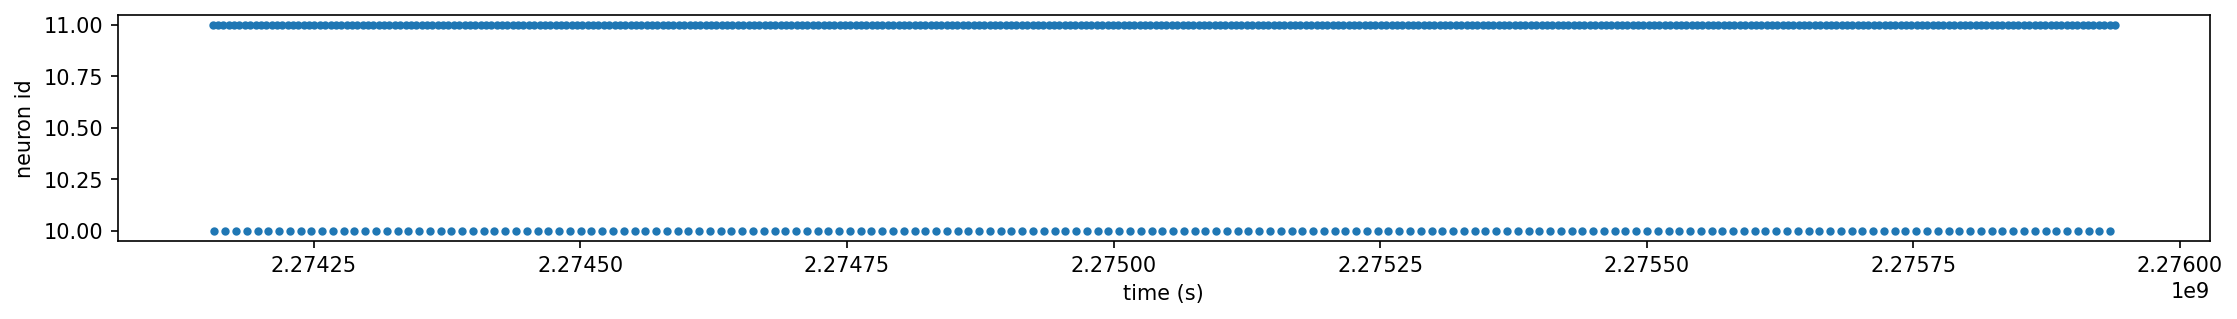

In [128]:
evts = sink_node.get_events()

print("Spikes collected:", len(evts))
evts_n = np.array([[evt.timestamp, evt.neuron_id] for evt in evts])

plt.figure(figsize=(18,2), dpi=150)
plt.plot(evts_n[:,0], evts_n[:,1], '.')
plt.xlabel("time (s)")
plt.ylabel("neuron id")

In [157]:
graph.stop()

True

# What about time varying input?

1257

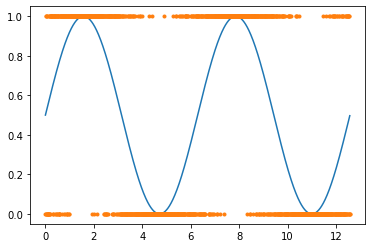

In [76]:
x = np.arange(0,4*np.pi,0.01)
y = np.sin(x)+1
y = y/y.max()
spikes = np.zeros(len(x))
spiketrain = []
for i in range(len(x)):
    if np.random.rand() < y[i]:
        spikes[i]=1

        
fig = plt.figure()
plt.plot(x,y)
plt.plot(x, spikes, '.')

len(spikes)

Text(0, 0.5, 'spikegen')

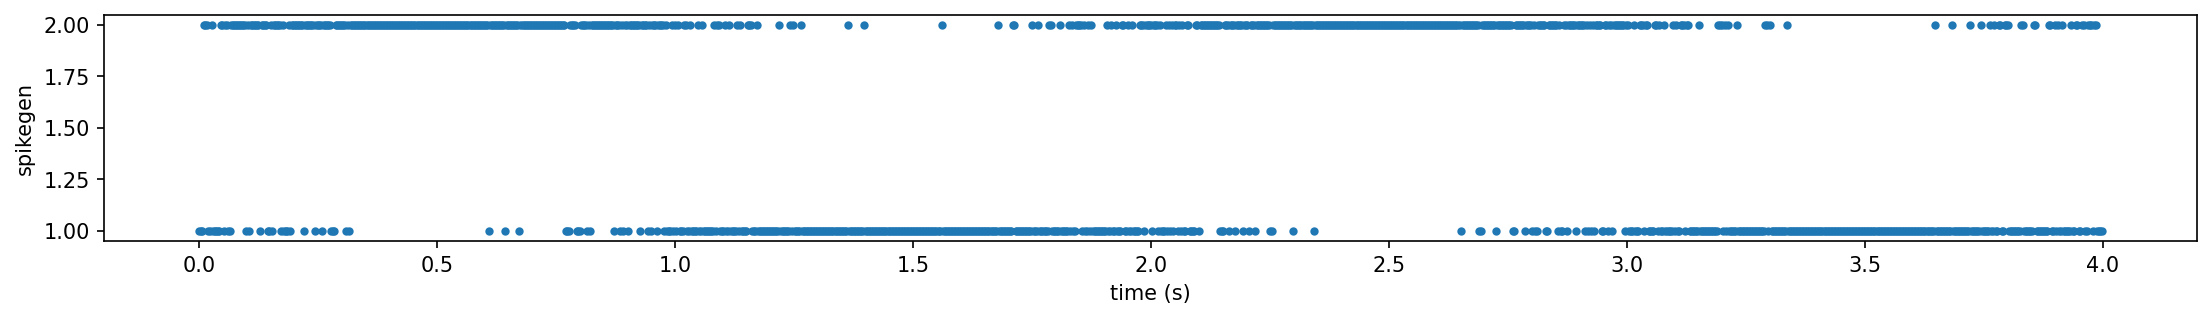

In [77]:
timestamps = 4*x/(4*np.pi)
indices = spikes+1

plt.figure(figsize=(18,2), dpi=150)
plt.plot(timestamps, indices, '.')
plt.xlabel("time (s)")
plt.ylabel("spikegen")

In [80]:
ut.set_fpga_spike_gen(fpga_spike_gen, spike_times=timestamps, indices=indices.astype(int), target_chips=[target_chip]*len(timestamps), isi_base=900, repeat_mode=True)

VariableIsiMode already 1
RepeatMode already 1


In [81]:
fpga_spike_gen.start()

In [79]:
fpga_spike_gen.stop()

### Let's see what all types of synapses are doing

In [82]:
net_gen = n.NetworkGenerator()

In [83]:
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.AMPA)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.NMDA)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.GABA_A)
net_gen.add_connection(spikegen_neuron1, neurons[0], dyn1.Dynapse1SynType.GABA_B)

In [84]:
net_gen.print_network()

Post neuron (ChipId,coreId,neuronId): incoming connections [(preNeuron,synapseType), ...]
C1c0n10: [('C0c0s1', 'AMPA'), ('C0c0s1', 'NMDA'), ('C0c0s1', 'GABA_A'), ('C0c0s1', 'GABA_B')]



In [85]:
new_config = net_gen.make_dynapse1_configuration()

In [86]:
model.apply_configuration(new_config)

array([[-0.1     ,  0.742031],
       [-0.0998  ,  0.743594],
       [-0.0996  ,  0.745547],
       ...,
       [ 0.0994  ,  0.706484],
       [ 0.0996  ,  0.707656],
       [ 0.0998  ,  0.708438]])

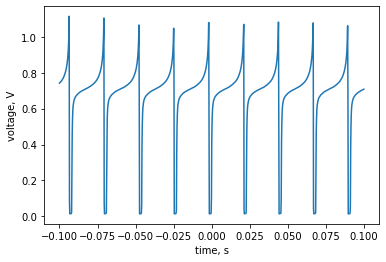

In [13]:
my_scope.get_waveform(channel=1, instant_plot=True)

## We can also automate network changes, right?

In [54]:
import STDP_plotter

neuron_ids = [10,11]

STDP_plotter.run_plotting_thread(neuron_ids, sink_node, refresh_rate = 500)

In [51]:
global_ids = np.array([10, 11])

In [52]:
graph, filter_node, sink_node = ut.create_neuron_select_graph(model, global_ids)

In [53]:
graph.start()

True

In [45]:
from importlib import reload
reload(STDP_plotter)

NameError: name 'STDP_plotter' is not defined

Stop the graph when it's no longer needed (for example for post-experiment data processing)

Let's have a gui that calculates the running average per neuron

In [222]:
%load_ext autoreload
%autoreload 2

Close the device at the end

In [ ]:
ut.close_dynapse1(store, device_name, gui_process)

In [ ]:
paramGroup1.param_map['IF_TAU1_N'].fine_value = 200
paramGroup1.param_map['IF_TAU1_N'].coarse_value = 6

model.update_parameter_group(
    paramGroup1, 0, 0)

In [ ]:
config = model.get_configuration()


In [ ]:
from bias_names import BIAS_NAMES

for bias_name in BIAS_NAMES:
    print(bias_name, param_group.get_linear_parameter(bias_name))

In [ ]:
param_group = config.chips[0].cores[0].parameter_group

model.update_parameter_group(
    param_group, 0, 0)

In [ ]:
linear_map = []

for coarse in range(0,8):
    for fine in range(0,256):
        paramGroup1.param_map['IF_TAU2_N'].fine_value = fine
        paramGroup1.param_map['IF_TAU2_N'].coarse_value = coarse
        
        linear = paramGroup1.get_linear_parameter('IF_TAU2_N')
        linear_map.append([coarse, fine, linear])
        
linear_map = np.array(linear_map)

In [ ]:
paramGroup1.param_map.keys()

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(np.array(linear_map))
plt.plot(linear_map_shrinked[:,2])

In [ ]:
plt.plot(np.log(linear_map_shrinked[:,2]))

In [ ]:
linear_map_shrinked = []

linear_map_shrinked = linear_map[0:256]
for coarse_id in range(1,8):
    full_map = linear_map[coarse_id*256:(coarse_id+1)*256]
    selected_range = np.where(full_map[:,2] > linear_map_shrinked[-1,2])
    linear_map_shrinked = np.concatenate((linear_map_shrinked,
                                          full_map[selected_range]))


In [ ]:
np.save("linear_fine_coarse_bias_map", linear_map_shrinked)

In [ ]:
linear_map_shrinked = np.array(linear_map_shrinked)

In [ ]:
 linear_map[coarse_id*256:(coarse_id+1)*256].shape

In [ ]:
linear_map_shrinked.shape

In [ ]:
api = model.get_dynapse1_api()

In [ ]:
dir(model)